# Inter-Node GPU Transfer Benchmark: Object Store vs Compiled Graph vs NCCL/RDMA

Compares three transport methods for a **1 GB float32 tensor** between two A6000 GPUs on
separate nodes (`digilab-receiver` ↔ `digilab-transmit`, connected by a 400G Mellanox ConnectX-7
RoCE v2 fabric).

| Method | Transport | Expected peak |
|--------|-----------|---------------|
| Ray Object Store | TCP via eno2 (10 GbE management) | ~1 GB/s |
| Compiled Graph (default) | TCP via object store protocol | ~1–5 GB/s |
| Compiled Graph + NCCL/RDMA | RoCE v2 via mlx5_0 (400G) | ~40+ GB/s |

**Prerequisites** (run once per environment):
```bash
conda install ray[cgraph]   # or: pip install "ray[cgraph]"
```

**NCCL env** is injected by `cluster/ral_up.sh` at cluster start. Confirm with:
```bash
NCCL_DEBUG=INFO python -c "import torch; torch.distributed.init_process_group('nccl')"
# Look for: "mlx5_0:1<0>" in the NCCL output — that's your RDMA path.
```

In [1]:
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
import ray
import seaborn as sns
import torch
from tqdm import tqdm

# Compiled graph warmup includes channel setup + NCCL group init on first execute,
# which can take 30–60 s for a 1 GB inter-node tensor. Must be set before
# experimental_compile() so the CompiledDAG picks up the value at construction time.
# Ray uses mixed-case here deliberately; noqa suppresses ruff's SIM112 uppercase check.
os.environ["RAY_CGRAPH_get_timeout"] = "120"  # noqa: SIM112

# Connect to the existing Ray cluster
ray.init(address="auto", ignore_reinit_error=True)

# 1 GB float32 tensor
TENSOR_SIZE_BYTES = 1 * 1024**3
TENSOR_SHAPE = (250_000_000,)

print(f"Ray Cluster Resources: {ray.available_resources()}")
print(f"Testing with Payload Size: {TENSOR_SIZE_BYTES / 1e9:.2f} GB")
print(f"Compiled graph get timeout: {os.environ['RAY_CGRAPH_get_timeout']} s")  # noqa: SIM112

# Set up plotting style for academic/HPC reporting
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

2026-06-11 01:28:43,359	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.1.14:6379...
2026-06-11 01:28:43,392	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://10.0.1.14:8265 


Ray Cluster Resources: {'memory': 193475914959.0, 'CPU': 88.0, 'node:10.0.1.34': 1.0, 'object_store_memory': 82918249265.0, 'accelerator_type:RTX': 2.0, 'GPU': 2.0, 'accelerator_type:A6000': 2.0, 'node:__internal_head__': 1.0, 'node:10.0.1.14': 1.0, 'node:10.0.1.38': 1.0, 'node:10.0.1.10': 1.0, 'node:10.0.1.18': 1.0}
Testing with Payload Size: 1.07 GB
Compiled graph get timeout: 120 s


/home/nico/miniconda3/envs/drp/lib/python3.14/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [2]:
@ray.remote(num_gpus=1)
class Sender:
    def __init__(self, shape):
        self.shape = shape
        self.tensor = torch.ones(self.shape, dtype=torch.float32, device="cuda")

    def get_data(self, trigger_input):  # <-- FIX: Added dummy parameter
        return self.tensor


@ray.remote(num_gpus=1)
class Receiver:
    def __init__(self):
        self.sink = None

    def consume_data(self, tensor):
        self.sink = tensor
        return True


# Instantiate the actors
sender = Sender.remote(TENSOR_SHAPE)
receiver = Receiver.remote()

# Warm up GPUs (pass a 0 as the dummy trigger)
ray.get(receiver.consume_data.remote(sender.get_data.remote(0)))
print("Actors initialized and warmed up.")

Actors initialized and warmed up.


In [3]:
import resource
import subprocess

issues = []


# Check RDMAV_FORK_SAFE and ulimit inside a real Ray worker process — that's where
# ibverbs actually runs. Checking os.environ in the notebook kernel is misleading
# because the kernel is a different process from the actors that use the RDMA NIC.
@ray.remote
def _worker_env_check():
    import os
    import resource as _r

    soft, _ = _r.getrlimit(_r.RLIMIT_MEMLOCK)
    return {
        "RDMAV_FORK_SAFE": os.environ.get("RDMAV_FORK_SAFE", ""),
        "ulimit_memlock_soft": soft,
        "RLIM_INFINITY": _r.RLIM_INFINITY,
        "NCCL_IB_GID_INDEX": os.environ.get("NCCL_IB_GID_INDEX", ""),
    }


@ray.remote
def _scan_gid_table():
    """Read /sys/class/infiniband/mlx5_0/ports/1/gids/ and return non-zero entries."""
    import os
    import socket

    gid_dir = "/sys/class/infiniband/mlx5_0/ports/1/gids"
    gids: dict[int, str] = {}
    if os.path.isdir(gid_dir):
        for entry in sorted(os.listdir(gid_dir), key=lambda x: int(x)):
            try:
                idx = int(entry)
                with open(f"{gid_dir}/{entry}") as fh:
                    gid = fh.read().strip()
                if gid not in ("0000:0000:0000:0000:0000:0000:0000:0000", ""):
                    gids[idx] = gid
            except Exception:
                pass
    return {"hostname": socket.gethostname(), "gids": gids}


env = ray.get(_worker_env_check.remote())

# nvidia_peermem must be checked first: it determines which NCCL data path is active
# and whether the locked-memory ulimit matters.
nvidia_peermem_loaded = False
try:
    lsmod_out = subprocess.check_output(["lsmod"], text=True)
    if "nvidia_peermem" in lsmod_out:
        nvidia_peermem_loaded = True
        print("OK  nvidia_peermem loaded → GPUDirect RDMA active (DMA-BUF, no CPU pinning)")
    else:
        print("INFO nvidia_peermem not loaded → NCCL will use CPU bounce (Shared path).")
        print("     Throughput lower than GPUDirect, but functional if ulimit is unlimited.")
        print("     To enable: sudo modprobe nvidia_peermem")
except Exception:
    print("INFO could not run lsmod")

# Locked-memory ulimit is only required for the CPU bounce (Shared) path.
# With GPUDirect active (nvidia_peermem loaded), NCCL uses DMA-BUF directly from
# GPU → NIC — no CPU buffers are pinned, so the ulimit is irrelevant.
if not nvidia_peermem_loaded:
    if env["ulimit_memlock_soft"] != env["RLIM_INFINITY"]:
        kb = env["ulimit_memlock_soft"] // 1024
        issues.append(
            f"  Worker locked-memory ulimit is {kb} KB (not unlimited).\n"
            "  Required for NCCL CPU bounce buffers when nvidia_peermem is absent.\n"
            "  Fix: re-run 'bash cluster/ral_up.sh' — ulimit -l unlimited is set there.\n"
            "  Note: if the system hard limit prevents unlimited, load nvidia_peermem instead."
        )
    else:
        print("OK  worker ulimit -l: unlimited (needed for CPU bounce path)")

if env["RDMAV_FORK_SAFE"] != "1":
    issues.append(
        f"  Worker RDMAV_FORK_SAFE='{env['RDMAV_FORK_SAFE']}' (expected '1').\n"
        "  Fix: re-run 'bash cluster/ral_up.sh' — RDMAV_FORK_SAFE=1 is set there."
    )
else:
    print("OK  worker RDMAV_FORK_SAFE=1")

# Scan the RoCEv2 GID table on every GPU node.
#
# Background: NCCL_IB_GID_INDEX selects which GID (source address) to use for
# ibv_modify_qp(RTR).  On this cluster ens7np0 has no configured IPv4 address, so
# GID 3 (IPv4 RoCEv2) is all-zero → ibv_modify_qp fails with errno 61 "No data
# available".  GID 0 is always present (link-local IPv6, fe80::...) and is correct
# for a single-switch L2 fabric — RoCEv2 over link-local IPv6 is L2-routed.
gpu_nodes = [n for n in ray.nodes() if n.get("Alive") and n.get("Resources", {}).get("GPU", 0) > 0]
gid_futures = [
    _scan_gid_table.options(resources={f"node:{n['NodeManagerAddress']}": 0.01}).remote()
    for n in gpu_nodes
]
gid_results = ray.get(gid_futures)

configured_idx_str = env["NCCL_IB_GID_INDEX"]
configured_idx = int(configured_idx_str) if configured_idx_str.isdigit() else -1

for result in gid_results:
    host = result["hostname"]
    gids = result["gids"]
    print(f"\n  {host} GID table (mlx5_0:1, non-zero entries):")
    if not gids:
        print("    (no non-zero GIDs found — is mlx5_0 UP?)")
        issues.append(f"  {host}: no valid GIDs found on mlx5_0:1")
    else:
        for idx, gid in sorted(gids.items()):
            marker = "  <-- in use (NCCL_IB_GID_INDEX)" if idx == configured_idx else ""
            print(f"    [{idx}] {gid}{marker}")
        if configured_idx not in gids:
            valid = sorted(gids.keys())
            issues.append(
                f"  {host}: NCCL_IB_GID_INDEX={configured_idx} is zero/missing "
                f"on mlx5_0:1  (valid indices: {valid}).\n"
                "  Fix: re-run 'bash cluster/ral_up.sh' — "
                "default is now NCCL_IB_GID_INDEX=0 (link-local IPv6, always present)."
            )

if issues:
    print("\n!! Prerequisites NOT met — §2/§3 will fail with NCCL_ERROR_SYSTEM_ERROR:")
    for msg in issues:
        print(msg)
    raise RuntimeError("Fix prerequisites above, then re-run from cell 1.")
else:
    print("\nAll prerequisites met.")

OK  nvidia_peermem loaded → GPUDirect RDMA active (DMA-BUF, no CPU pinning)
OK  worker RDMAV_FORK_SAFE=1

  digilab-receiver GID table (mlx5_0:1, non-zero entries):
    [0] fe80:0000:0000:0000:a288:c2ff:fe0d:5e28  <-- in use (NCCL_IB_GID_INDEX)
    [1] fe80:0000:0000:0000:a288:c2ff:fe0d:5e28

  digilab-transmit GID table (mlx5_0:1, non-zero entries):
    [0] fe80:0000:0000:0000:966d:aeff:feac:f838  <-- in use (NCCL_IB_GID_INDEX)
    [1] fe80:0000:0000:0000:966d:aeff:feac:f838

All prerequisites met.


## §1 Baseline: Ray Object Store (TCP, inter-node)

Both actors carry `num_gpus=1` — with 1 GPU per node the scheduler places them on
separate nodes automatically. The object store path serialises the tensor through CPU
memory and sends it over the 10 GbE management interface (`eno2`).

In [4]:
def benchmark_object_store(iterations=20):
    records = []
    print(f"Running Baseline (Object Store) for {iterations} iterations...")

    for i in tqdm(range(iterations)):
        start_time = time.perf_counter()

        # Standard Ray object store transfer — inter-node when actors land on separate nodes
        data_ref = sender.get_data.remote(0)
        ready_ref = receiver.consume_data.remote(data_ref)
        ray.get(ready_ref)

        end_time = time.perf_counter()
        iteration_time = end_time - start_time

        records.append(
            {
                "Method": "Ray Object Store (inter-node)",
                "Iteration": i + 1,
                "Latency (ms)": iteration_time * 1000,
                "Throughput (GB/s)": (TENSOR_SIZE_BYTES / 1e9) / iteration_time,
            }
        )

    return pd.DataFrame(records)


df_baseline = benchmark_object_store(iterations=10)

Running Baseline (Object Store) for 5 iterations...


100%|██████████████████████████████████████████████████████████████████████| 5/5 [01:03<00:00, 12.68s/it]


In [5]:
# No NodeAffinitySchedulingStrategy — actors land on separate nodes automatically when the
# cluster has 1 GPU per node, measuring true inter-node 400G RDMA transfer performance.
# (The old same-node pin was measuring intra-node NVLink/PCIe, not the RDMA fabric.)
print(f"Sender:   {sender}")
print(f"Receiver: {receiver}")

Sender:   Actor(Sender, 103256aee5ee299106de89ba02000000)
Receiver: Actor(Receiver, 3a4cb709240fb0521e4b127802000000)


## §2 Compiled Graph — default transport (no explicit NCCL)

Ray's compiled graph skips the Python-level serialisation overhead but still uses the
object store protocol under the hood unless a tensor transport is specified. This gives
the compiled-graph scheduling benefit without RDMA, so it's the right control to isolate
the NCCL/RDMA contribution in §3.

In [22]:
import contextlib

# Only one compiled DAG can be active per actor at a time.  Tear down any live
# DAG before compiling a new one so §2 and §3 can be re-run in any order.
for _dag in [globals().get("compiled_dag_default"), globals().get("compiled_dag_nccl")]:
    if _dag is not None:
        with contextlib.suppress(Exception):
            _dag.teardown()

from ray.dag.input_node import InputNode

# Compiled graph WITHOUT explicit NCCL transport — uses Ray's default protocol.
with InputNode() as inp:
    data = sender.get_data.bind(inp)
    result_default = receiver.consume_data.bind(data)

compiled_dag_default = result_default.experimental_compile()

# Warmup pass (not measured)
ray.get(compiled_dag_default.execute(0))

def benchmark_compiled_graph_default(iterations=20):
    records = []
    print(f"Running Compiled Graph (default transport) for {iterations} iterations...")
    for i in tqdm(range(iterations)):
        t0 = time.perf_counter()
        ray.get(compiled_dag_default.execute(i))
        elapsed = time.perf_counter() - t0
        records.append(
            {
                "Method": "Compiled Graph (default)",
                "Iteration": i + 1,
                "Latency (ms)": elapsed * 1000,
                "Throughput (GB/s)": (TENSOR_SIZE_BYTES / 1e9) / elapsed,
            }
        )
    return pd.DataFrame(records)

df_default = benchmark_compiled_graph_default(iterations=10)
print(f"Mean throughput: {df_default['Throughput (GB/s)'].mean():.2f} GB/s")
# compiled_dag_default.teardown()


2026-06-11 01:41:19,618	INFO compiled_dag_node.py:2167 -- Tearing down compiled DAG
2026-06-11 01:41:19,620	INFO compiled_dag_node.py:2172 -- Cancelling compiled worker on actor: Actor(Sender, 103256aee5ee299106de89ba02000000)
2026-06-11 01:41:19,621	INFO compiled_dag_node.py:2172 -- Cancelling compiled worker on actor: Actor(Receiver, 3a4cb709240fb0521e4b127802000000)
(Receiver pid=144213, ip=10.0.1.34) Destructing NCCL group on actor: Actor(Receiver, 3a4cb709240fb0521e4b127802000000)
(Sender pid=1976634) Destructing NCCL group on actor: Actor(Sender, 103256aee5ee299106de89ba02000000)


(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO ENV/Plugin: Could not find: libnccl-env.so
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO NCCL_SOCKET_IFNAME set by environment to eno2
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO Bootstrap: Using eno2:10.0.1.34<0>
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO cudaDriverVersion 13000
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO NCCL version 2.29.7+cuda13.2
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO NCCL git version stable b81d6a5a3
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO NET/Plugin: Could not find: libnccl-net.so
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:144213:144213 [0] NCCL INFO NCCL_IB_DISABLE set by environment to 0.
(Receiver pid=144213, ip=10.0.1.34) digilab-transmit:1442

2026-06-11 01:41:20,147	INFO compiled_dag_node.py:2194 -- Waiting for worker tasks to exit
2026-06-11 01:41:20,149	INFO compiled_dag_node.py:2197 -- Teardown complete


Running Compiled Graph (default transport) for 2 iterations...


100%|██████████████████████████████████████████████████████████████████████| 2/2 [00:21<00:00, 10.74s/it]
2026-06-11 01:41:54,226	INFO compiled_dag_node.py:2167 -- Tearing down compiled DAG
2026-06-11 01:41:54,228	INFO compiled_dag_node.py:2172 -- Cancelling compiled worker on actor: Actor(Sender, 103256aee5ee299106de89ba02000000)
2026-06-11 01:41:54,228	INFO compiled_dag_node.py:2172 -- Cancelling compiled worker on actor: Actor(Receiver, 3a4cb709240fb0521e4b127802000000)
2026-06-11 01:41:54,235	INFO compiled_dag_node.py:2194 -- Waiting for worker tasks to exit


Mean throughput: 0.10 GB/s


2026-06-11 01:42:24,238	WARNING compiled_dag_node.py:2135 -- Compiled DAG actor Actor(Receiver, 3a4cb709240fb0521e4b127802000000) is still running 30s after teardown(). Teardown may hang. Call teardown with kill_actors=True if force kill is desired.


KeyboardInterrupt: 

## §3 Compiled Graph + NCCL/RDMA (400G RoCE v2)

`.with_tensor_transport("nccl")` on the GPU→GPU edge routes the tensor directly through
NCCL's collective transport layer, which picks the RDMA path (`mlx5_0`) when the
`NCCL_IB_*` env vars are set. This bypasses CPU memory entirely for the data movement.

In [7]:
import contextlib

ray.init(address="auto", ignore_reinit_error=True)

# Only one compiled DAG can be active per actor at a time.  Tear down any live
# DAG before compiling a new one so §2 and §3 can be re-run in any order.
for _dag in [globals().get("compiled_dag_default"), globals().get("compiled_dag_nccl")]:
    if _dag is not None:
        with contextlib.suppress(Exception):
            _dag.teardown()

from ray.dag.input_node import InputNode

# Compiled graph WITH NCCL tensor transport on the GPU-to-GPU edge.
with InputNode() as inp:
    data = sender.get_data.bind(inp)
    result = receiver.consume_data.bind(data.with_tensor_transport("nccl"))

compiled_dag_nccl = result.experimental_compile()


2026-06-11 01:30:05,326	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.1.14:6379...
2026-06-11 01:30:05,327	INFO worker.py:1828 -- Calling ray.init() again after it has already been called.
2026-06-11 01:30:05,421	INFO torch_tensor_accelerator_channel.py:807 -- Creating communicator group bcb30941-fe79-4ae9-a2b7-b0a032691eda on actors: [Actor(Receiver, 3a4cb709240fb0521e4b127802000000), Actor(Sender, 103256aee5ee299106de89ba02000000)]
2026-06-11 01:30:05,792	INFO torch_tensor_accelerator_channel.py:833 -- Communicator group initialized.


In [8]:
# Warmup pass (not measured)
ray.get(compiled_dag_nccl.execute(0))

True

In [9]:
def benchmark_compiled_graph_nccl(iterations=20):
    records = []
    print(f"Running Compiled Graph (NCCL/RDMA) for {iterations} iterations...")
    for i in tqdm(range(iterations)):
        t0 = time.perf_counter()
        ray.get(compiled_dag_nccl.execute(i))
        elapsed = time.perf_counter() - t0
        records.append(
            {
                "Method": "Compiled Graph (NCCL/RDMA)",
                "Iteration": i + 1,
                "Latency (ms)": elapsed * 1000,
                "Throughput (GB/s)": (TENSOR_SIZE_BYTES / 1e9) / elapsed,
            }
        )
    return pd.DataFrame(records)


df_nccl = benchmark_compiled_graph_nccl(iterations=200)
print(f"Mean throughput: {df_nccl['Throughput (GB/s)'].mean():.2f} GB/s")
# compiled_dag_nccl.teardown(kill_actors=True)


Running Compiled Graph (NCCL/RDMA) for 200 iterations...


100%|██████████████████████████████████████████████████████████████████| 200/200 [00:10<00:00, 19.80it/s]

Mean throughput: 21.45 GB/s


In [23]:
df_results = pd.concat([df_baseline, df_default, df_nccl], ignore_index=True)
# df_results = pd.concat([df_baseline, df_nccl], ignore_index=True)
# df_results = pd.concat([df_nccl], ignore_index=True)


print("\nBenchmarking complete. Summary:")
print(
    df_results.groupby("Method")["Throughput (GB/s)"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "mean (GB/s)", "std": "std (GB/s)"})
    .to_string()
)


Benchmarking complete. Summary:
                               mean (GB/s)  std (GB/s)
Method                                                
Compiled Graph (NCCL/RDMA)       21.448470    0.297360
Compiled Graph (default)          0.099969    0.000341
Ray Object Store (inter-node)     0.084685    0.001073


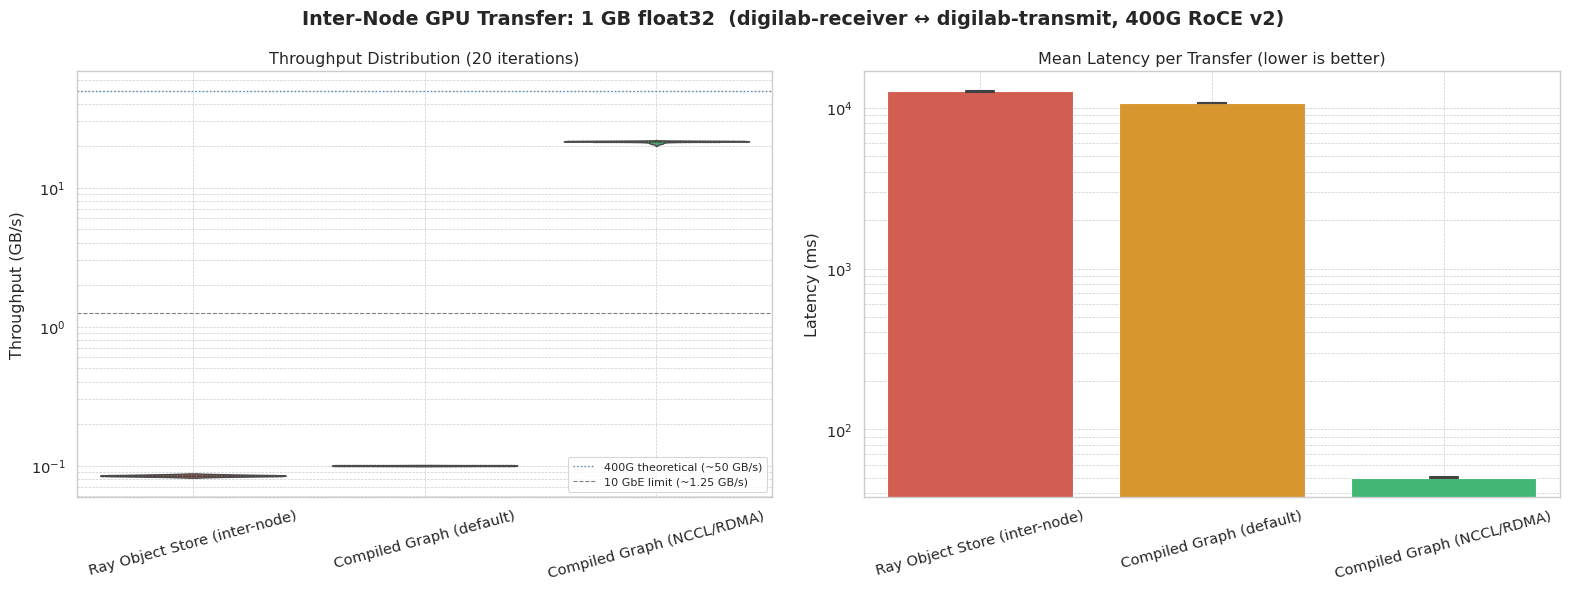


--- Summary Statistics ---
                              Throughput (GB/s)                                  Latency (ms)                                        
                                           mean       std        min        max          mean         std           min           max
Method                                                                                                                               
Ray Object Store (inter-node)          0.084685  0.001073   0.083278   0.086220  12680.911753  160.438791  12453.533520  12893.416663
Compiled Graph (default)               0.099969  0.000341   0.099728   0.100211  10740.757352   36.629402  10714.856454  10766.658251
Compiled Graph (NCCL/RDMA)            21.448470  0.297360  20.088127  21.786536     50.071345    0.716398     49.284651     53.451566

--- Speedup vs Object Store Baseline ---
  Compiled Graph (default): 1.2×
  Compiled Graph (NCCL/RDMA): 253.3×


In [24]:
PALETTE = {
    "Ray Object Store (inter-node)": "#e74c3c",
    "Compiled Graph (default)": "#f39c12",
    "Compiled Graph (NCCL/RDMA)": "#2ecc71",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Inter-Node GPU Transfer: {TENSOR_SIZE_BYTES / 1e9:.0f} GB float32  "
    f"(digilab-receiver ↔ digilab-transmit, 400G RoCE v2)",
    fontweight="bold",
)

# Throughput violin
sns.violinplot(
    data=df_results,
    x="Method",
    y="Throughput (GB/s)",
    ax=axes[0],
    palette=PALETTE,
    hue="Method",
    inner="quartile",
    order=list(PALETTE.keys()),
)
axes[0].set_title("Throughput Distribution (20 iterations)")
axes[0].set_ylabel("Throughput (GB/s)")
axes[0].set_yscale('log')
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)
axes[0].axhline(50.0, color="steelblue", linestyle=":", lw=1.0, label="400G theoretical (~50 GB/s)")
axes[0].axhline(1.25, color="gray", linestyle="--", lw=0.8, label="10 GbE limit (~1.25 GB/s)")
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].legend(fontsize=8)

# Latency bar
sns.barplot(
    data=df_results,
    x="Method",
    y="Latency (ms)",
    ax=axes[1],
    palette=PALETTE,
    hue="Method",
    order=list(PALETTE.keys()),
    capsize=0.12,
    err_kws={"linewidth": 1.5},
)
axes[1].set_title("Mean Latency per Transfer (lower is better)")
axes[1].set_ylabel("Latency (ms)")
axes[1].set_yscale('log')
axes[1].set_xlabel("")
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
# axes[1].minorticks_on()
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("\n--- Summary Statistics ---")
summary = (
    df_results.groupby("Method")[["Throughput (GB/s)", "Latency (ms)"]]
    .agg(["mean", "std", "min", "max"])
    .reindex(list(PALETTE.keys()))
)
print(summary.to_string())

# Speedup factors vs object store baseline
base_mean = df_results[df_results["Method"] == "Ray Object Store (inter-node)"][
    "Throughput (GB/s)"
].mean()
print("\n--- Speedup vs Object Store Baseline ---")
for method in list(PALETTE.keys())[1:]:
    m = df_results[df_results["Method"] == method]["Throughput (GB/s)"].mean()
    print(f"  {method}: {m / base_mean:.1f}×")

## §4 Interpreting results & NCCL_DEBUG

### What to expect
| Transport | Mechanism | Bottleneck |
|-----------|-----------|------------|
| Object store | TCP → CPU RAM → TCP | 10 GbE NIC (`eno2`), ~1 GB/s |
| Compiled graph (default) | Same serialisation, less scheduling overhead | 10 GbE, ~1–5 GB/s |
| NCCL/RDMA | `mlx5_0` RDMA write (zero-copy GPU→GPU) | PCIe or 400G fabric, target >40 GB/s |

If NCCL/RDMA throughput is **not** significantly higher than the object store baseline,
check the NCCL transport selection — it may have fallen back to TCP.

### Compiled graph timeout
`RAY_CGRAPH_get_timeout` (set to 120 s in cell 1) controls how long the calling process
waits for each `compiled_dag.execute()` to return a result. The default is 10 s, which
is too short for:
- **First execution of default transport**: channel setup + 1 GB inter-node transfer (~5–15 s)
- **First execution of NCCL transport**: NCCL process group init + RDMA handshake (~15–60 s)

Subsequent iterations are fast once channels are warm. If you still see timeouts, raise
the value further: `os.environ["RAY_CGRAPH_get_timeout"] = "300"` and re-run cells 1–9.

### GID index — the most common RoCEv2 pitfall
`NCCL_IB_GID_INDEX` selects the source address NCCL embeds in every RoCEv2 packet when
calling `ibv_modify_qp(RTR)`.  If the index points to an all-zero GID, the call fails with
errno 61 "No data available" and NCCL aborts with `NCCL_ERROR_SYSTEM_ERROR`.

On this cluster `ens7np0` (the ConnectX-7 RDMA NIC) has **no configured IPv4 address**,
so only GID 0 exists — it carries the link-local IPv6 (`fe80::...`) that every NIC
auto-assigns.  GID 3 (IPv4 RoCEv2) would require an IP on `ens7np0` and is all-zero here.

`cluster/ral_up.sh` defaults to `NCCL_IB_GID_INDEX=0`.  The prerequisite cell above
verifies this by scanning `/sys/class/infiniband/mlx5_0/ports/1/gids/` on each GPU node
and comparing the configured index against the actual non-zero entries.

If you ever add an IPv4 address to `ens7np0` for higher-throughput RoCEv2, the correct
index can then be found from `show_gids` or `ibv_devinfo -v -d mlx5_0 | grep GID` and
set via `NCCL_IB_GID_INDEX=<n> bash cluster/ral_up.sh --no-sync`.

### Reading NCCL_DEBUG=INFO output
After `cluster/ral_up.sh` restarts the cluster, the DDP init log will contain lines like:
```
NCCL INFO NET/IB : Using [0]mlx5_0:1/RoCE [RO]; OOB eno2:10.0.1.14<0>
NCCL INFO Channel 00/02: 0[0] -> 1[0] via NET/IB/0/Direct
```
`NET/IB/0/Direct` confirms GPUDirect RDMA (requires `nvidia_peermem`).
`NET/IB/0/Shared` is the CPU-bounce path (works without `nvidia_peermem`, lower throughput).
`P2P/NET/Socket` means TCP fallback — check `NCCL_IB_*` vars.

### Tuning knobs
```bash
# Override per-run without editing ral_up.sh (e.g. after assigning an IP to ens7np0):
NCCL_IB_HCA=mlx5_0 NCCL_IB_GID_INDEX=1 bash cluster/ral_up.sh --no-sync

# Increase NCCL buffer for large tensors (optional):
export NCCL_BUFFSIZE=8388608   # 8 MB (default 4 MB)
```
